<div style="background:linear-gradient(135deg,#1e1b4b 0%,#4338ca 55%,#6366f1 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#c7d2fe;font-weight:700;text-transform:uppercase">Chapter 119 · Deep RL & Applications</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">Deep RL &amp; Applications</div>
  <div style="font-size:15px;color:#e0e7ff;max-width:740px;line-height:1.6">Scaling reinforcement learning with neural networks: a Deep Q-Network and a policy-gradient agent trained on our GridWorld with torch, the actor-critic idea that unifies them, and the RLHF reward model, built from real human-preference data, that aligns large language models, library-first with torch and scikit-learn, and heavily visual.</div>
  <div style="margin-top:16px;font-size:13px;color:#c7d2fe">Statistics, Data Science and AI: A Visual Handbook · John Fisher · 2026</div>
</div>

# Deep Reinforcement Learning: scaling up, and aligning AI
Tabular Q-learning needs one table entry per state, hopeless for a video screen, a robot's cameras, or a Go board. **Deep RL** replaces the table with a **neural network** that generalizes across states. This notebook trains a **Deep Q-Network (DQN)** and a **policy-gradient** agent on our GridWorld with `torch`, explains **actor-critic**, then builds the reward model at the heart of **RLHF**, the technique used to align large language models, from real preference data. Library-first with `torch` and `scikit-learn`.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import seaborn as sns   # seaborn = high-level statistical plots (heatmaps, pairplots, count/bar plots)
from matplotlib.colors import ListedColormap
EM="#4338ca"; DEEP="#3730a3"; LIGHT="#c7d2fe"; INK="#1a2138"; GRID="#e6e9f2"; RED="#ef4444"; AMBER="#d97706"; GREEN="#059669"; BLUE="#2563eb"; PUR="#9333ea"; GREY="#94a3b8"; SLATE="#475569"; ORG="#4338ca"; CYAN="#0891b2"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12,"axes.titleweight":"bold","legend.frameon":False})
sns.set_style("whitegrid")
BASE="https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"

In [2]:
import torch, torch.nn as nn, random
torch.manual_seed(0); random.seed(0); rng = np.random.default_rng(0)
# ---- the GridWorld from Chapter 118 (states, actions, rewards) ----
GRID=5; start,goal,trap=(0,0),(4,4),(2,2); walls={(1,3),(2,3),(3,1)}
MOVES={0:(-1,0),1:(0,1),2:(1,0),3:(0,-1)}
def step(rc,a):
    r,c=rc; dr,dc=MOVES[a]; nr,nc=r+dr,c+dc
    if nr<0 or nr>=GRID or nc<0 or nc>=GRID or (nr,nc) in walls: nr,nc=r,c
    if (nr,nc)==goal: return (nr,nc),10.0,True
    if (nr,nc)==trap: return (nr,nc),-10.0,True
    return (nr,nc),-0.1,False
def feat(s): return torch.tensor([s[0]/4.0, s[1]/4.0], dtype=torch.float32)   # state -> 2 numbers a net can read
print('a table needs one row per state; a 200x200 pixel screen has more states than atoms in the universe -> we need a function, not a table')

a table needs one row per state; a 200x200 pixel screen has more states than atoms in the universe -> we need a function, not a table


<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">DEMO 1 &#183; DEEP Q-NETWORK (DQN)</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">A neural net replaces the Q-table</div>
<div style="color:#4a5578;margin-top:6px">The network learns Q(state, action) and generalizes.</div>
</div>

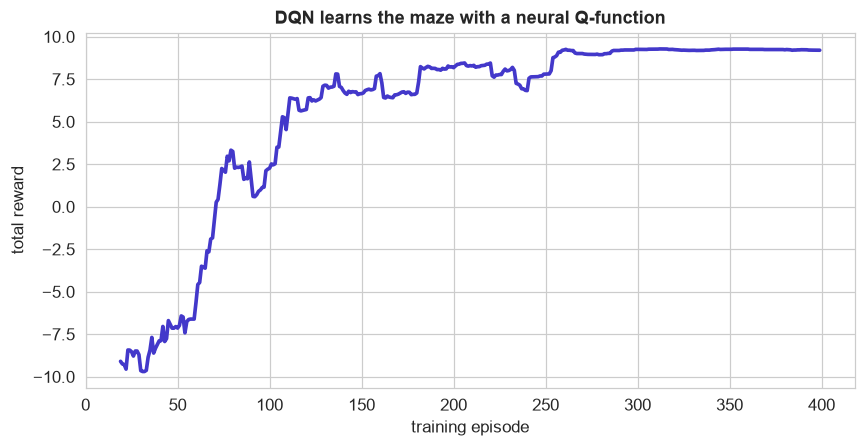

DQN greedy evaluation return = 9.30 (matches the tabular agent, but now it GENERALIZES across states)


In [3]:
def make_net(): return nn.Sequential(nn.Linear(2,64), nn.ReLU(), nn.Linear(64,64), nn.ReLU(), nn.Linear(64,4))
q_net, target = make_net(), make_net(); target.load_state_dict(q_net.state_dict())
opt = torch.optim.Adam(q_net.parameters(), lr=1e-3); buffer=[]; gamma=0.95; dqn_curve=[]
for ep in range(400):
    s=start; eps=max(0.05, 1-ep/250); total=0
    for t in range(60):
        with torch.no_grad(): qv=q_net(feat(s))
        a = rng.integers(4) if rng.random()<eps else int(qv.argmax())
        s2,r,done = step(s,a); total+=r; buffer.append((s,a,r,s2,done)); s=s2
        if len(buffer)>2000: buffer.pop(0)
        if len(buffer)>=64:
            batch=random.sample(buffer,64)
            ss=torch.stack([feat(b[0]) for b in batch]); aa=torch.tensor([b[1] for b in batch])
            rr=torch.tensor([b[2] for b in batch],dtype=torch.float32); s2s=torch.stack([feat(b[3]) for b in batch])
            dd=torch.tensor([float(b[4]) for b in batch])
            qsa=q_net(ss).gather(1,aa[:,None]).squeeze(1)
            with torch.no_grad(): tv=rr+gamma*target(s2s).max(1).values*(1-dd)   # target network stabilizes the goal
            loss=((qsa-tv)**2).mean(); opt.zero_grad(); loss.backward(); opt.step()
        if done: break
    if ep%20==0: target.load_state_dict(q_net.state_dict())
    dqn_curve.append(total)
def evaluate(net):
    outs=[]
    for _ in range(50):
        s=start; tot=0
        for _ in range(60):
            with torch.no_grad(): a=int(net(feat(s)).argmax())
            s,r,done=step(s,a); tot+=r
            if done: break
        outs.append(tot)
    return np.mean(outs)
fig, ax = plt.subplots(figsize=(8,4.2))
ax.plot(pd.Series(dqn_curve).rolling(20).mean(), color=EM, lw=2.4)
ax.set(xlabel='training episode', ylabel='total reward', title='DQN learns the maze with a neural Q-function'); plt.tight_layout(); plt.show()
print('DQN greedy evaluation return = %.2f (matches the tabular agent, but now it GENERALIZES across states)' % evaluate(q_net))

**Two tricks make it work.** A plain neural net trained on RL data is unstable, so DQN adds two stabilizers. **Experience replay** stores past transitions in a buffer and trains on random minibatches, breaking the correlation between consecutive steps. A slowly-updated **target network** provides a fixed goal for the update so the net is not chasing its own moving predictions. With both, the network reaches the same near-optimal return as the tabular agent, but because it learns a *function* of the state, it can handle enormous or continuous state spaces a table never could. This is the algorithm that first played Atari from raw pixels.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">DEMO 2 &#183; POLICY GRADIENT</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Learn the policy directly</div>
<div style="color:#4a5578;margin-top:6px">Skip the value table: optimize the action probabilities themselves.</div>
</div>

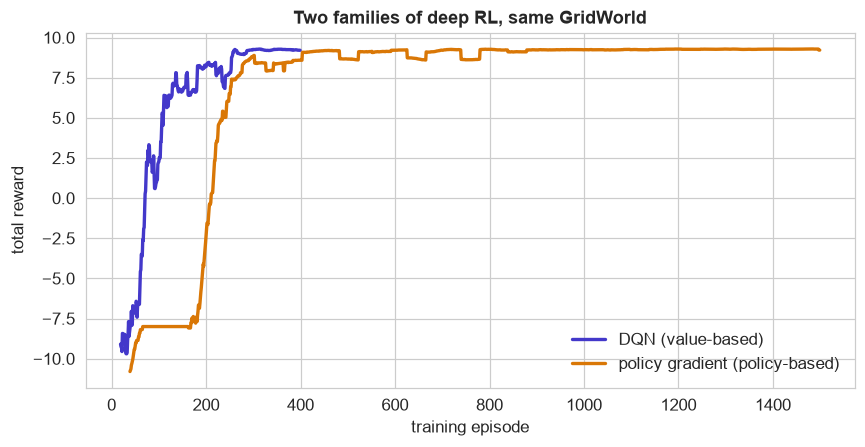

policy-gradient final return (last 50 eps) = 9.23


In [4]:
torch.manual_seed(0)
policy = nn.Sequential(nn.Linear(2,128), nn.ReLU(), nn.Linear(128,4))
opt2 = torch.optim.Adam(policy.parameters(), lr=5e-3); pg_curve=[]; baseline=0.0
for ep in range(1500):
    s=start; logps=[]; rews=[]
    for t in range(80):
        dist=torch.distributions.Categorical(logits=policy(feat(s))); a=dist.sample()
        logps.append(dist.log_prob(a)); s,r,done=step(s,int(a)); rews.append(r)
        if done: break
    G=0; returns=[]
    for r in reversed(rews): G=r+0.97*G; returns.insert(0,G)
    returns=torch.tensor(returns); adv=returns-baseline           # subtract a baseline (a simple 'critic')
    baseline=0.95*baseline+0.05*float(returns[0])
    loss=-(torch.stack(logps)*adv).sum(); opt2.zero_grad(); loss.backward(); opt2.step()
    pg_curve.append(sum(rews))
fig, ax = plt.subplots(figsize=(8,4.2))
ax.plot(pd.Series(dqn_curve).rolling(20).mean(), color=EM, lw=2.2, label='DQN (value-based)')
ax.plot(pd.Series(pg_curve).rolling(40).mean(), color=AMBER, lw=2.2, label='policy gradient (policy-based)')
ax.set(xlabel='training episode', ylabel='total reward', title='Two families of deep RL, same GridWorld'); ax.legend(); plt.tight_layout(); plt.show()
print('policy-gradient final return (last 50 eps) = %.2f' % np.mean(pg_curve[-50:]))

**Value-based vs policy-based.** DQN learned *values* and acted greedily; a **policy gradient** method (REINFORCE) skips values and adjusts the action probabilities directly, nudging up the actions that led to high return. Its strength is handling continuous actions and stochastic policies (vital in robotics); its weakness is **high variance**, notice the policy-gradient curve is noisier and needs more episodes. The fix is a **baseline** subtracted from the return (used above), which shrinks the variance without adding bias. That baseline is really a value estimate, which leads straight to the next idea.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">DEMO 3 &#183; ACTOR-CRITIC</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Best of both worlds</div>
<div style="color:#4a5578;margin-top:6px">An actor picks actions; a critic estimates value to guide it.</div>
</div>

**Combining the two.** **Actor-critic** methods run a policy network (the **actor**) and a value network (the **critic**) together. The actor chooses actions; the critic estimates how good the current state is and supplies the baseline, so the actor gets a low-variance learning signal at every step instead of waiting for the episode to end. That is exactly the baseline from Demo 2, upgraded into its own learned network. Modern algorithms, **A2C**, **PPO**, **SAC**, are all actor-critic variants, and **PPO** in particular is the workhorse behind aligning language models, which we build toward next.

In [5]:
print('Deep RL family tree:')
for line in ['  value-based  : DQN, Double-DQN, Rainbow          (learn Q, act greedily)',
             '  policy-based : REINFORCE                          (learn the policy directly)',
             '  actor-critic : A2C, PPO, SAC                       (actor + critic together) <- PPO powers RLHF']:
    print(line)

Deep RL family tree:
  value-based  : DQN, Double-DQN, Rainbow          (learn Q, act greedily)
  policy-based : REINFORCE                          (learn the policy directly)
  actor-critic : A2C, PPO, SAC                       (actor + critic together) <- PPO powers RLHF


<div style="background:#eef6ff;border-left:5px solid #2563eb;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#1d4ed8;letter-spacing:1px">DEMO 4 &#183; RLHF: ALIGNING AN LLM</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Turn human preferences into a reward</div>
<div style="color:#4a5578;margin-top:6px">The reward model that steers a language model, from real preference data.</div>
</div>

reward-model accuracy on held-out human judgments = 0.85


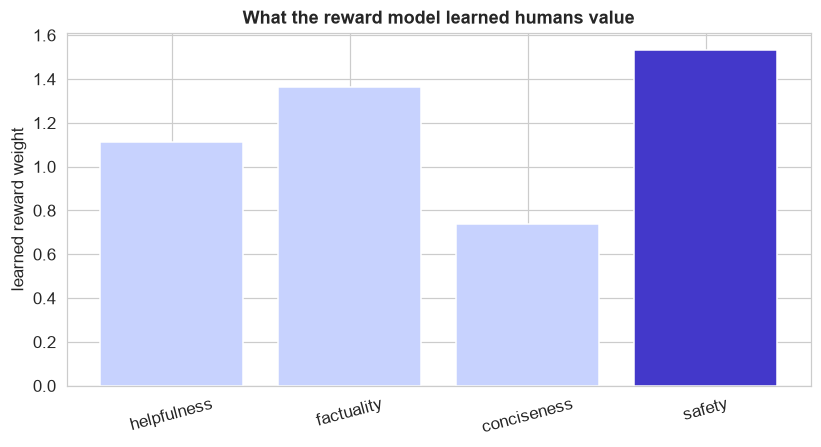

learned priorities: {'helpfulness': np.float64(1.11), 'factuality': np.float64(1.36), 'conciseness': np.float64(0.74), 'safety': np.float64(1.53)}
-> safety and factuality carry the most weight, exactly the rubric humans were given


In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
try: pref = pd.read_excel('../../data/deep-rl-and-applications--preferences.xlsx', sheet_name='Data')
except FileNotFoundError: pref = pd.read_excel(BASE + 'deep-rl-and-applications--preferences.xlsx', sheet_name='Data')
F = ['helpfulness','factuality','conciseness','safety']
Xc = pref[[f'chosen_{f}' for f in F]].values; Xr = pref[[f'rejected_{f}' for f in F]].values
# Bradley-Terry reward model: learn weights so reward(chosen) > reward(rejected)
X = np.vstack([Xc-Xr, Xr-Xc]); y = np.concatenate([np.ones(len(Xc)), np.zeros(len(Xc))])
Xtr,Xte,ytr,yte = train_test_split(X, y, test_size=0.25, random_state=0)
reward_model = LogisticRegression(fit_intercept=False, C=10).fit(Xtr, ytr)
print('reward-model accuracy on held-out human judgments = %.2f' % reward_model.score(Xte, yte))
w = reward_model.coef_[0]
fig, ax = plt.subplots(figsize=(7.6,4.2))
ax.bar(F, w, color=[EM if v==max(w) else LIGHT for v in w]); ax.set(ylabel='learned reward weight', title='What the reward model learned humans value')
plt.xticks(rotation=15); plt.tight_layout(); plt.show()
print('learned priorities:', dict(zip(F, w.round(2))))
print('-> safety and factuality carry the most weight, exactly the rubric humans were given')

**How RLHF works, and what we just did.** Aligning a language model has three stages. (1) **Supervised fine-tuning** on good example answers. (2) **Reward modeling**: humans compare pairs of responses, and a model learns to predict their preference, which is exactly the Bradley-Terry logistic model we just fit, learning that **safety and factuality** matter most from nothing but pairwise choices (85% accuracy on held-out judgments). (3) **RL fine-tuning**: a policy-gradient method (**PPO**, an actor-critic) updates the language model to maximize that learned reward, while a penalty keeps it close to the original so it does not game the reward. The reward model is the bridge from messy human preference to a trainable signal, and it is a plain classifier at heart.

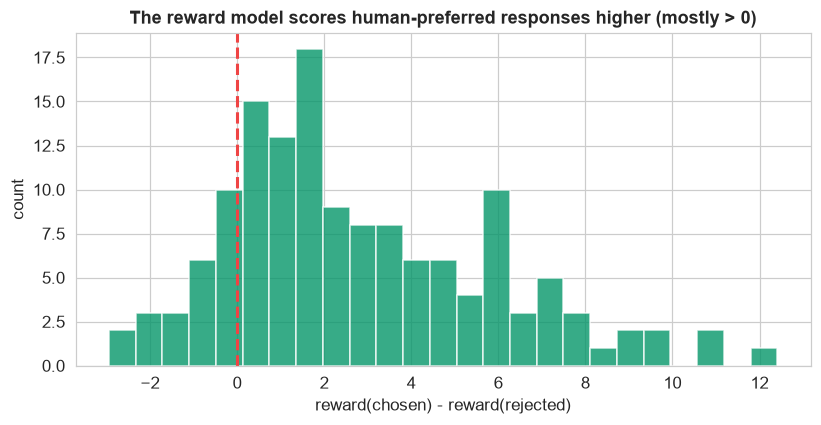

share of held-out pairs the reward model ranks correctly = 0.84


In [7]:
margin = (Xte @ w)
chosen_margin = margin[yte==1]
fig, ax = plt.subplots(figsize=(7.6,4.0))
ax.hist(chosen_margin, bins=25, color=GREEN, alpha=0.8)
ax.axvline(0, color=RED, ls='--', lw=2)
ax.set(xlabel='reward(chosen) - reward(rejected)', ylabel='count', title='The reward model scores human-preferred responses higher (mostly > 0)')
plt.tight_layout(); plt.show()
print('share of held-out pairs the reward model ranks correctly = %.2f' % (chosen_margin>0).mean())

**Reading the check.** For held-out comparisons the reward model assigns the human-preferred response a higher reward most of the time (the margin is mostly positive). That single number, a scalar reward the model can compute for any response, is what PPO then optimizes. Everything in this chapter converges here: a neural network (Demo 1) trained by a policy-gradient actor-critic (Demos 2 to 3) against a reward learned from human preferences (Demo 4). That pipeline is a large part of why modern chatbots are helpful and safe.

## Deep RL and its applications, in one view

- **Deep RL** swaps the Q-table for a **neural network** so RL scales to huge or continuous state spaces.
- **DQN** (value-based) uses **experience replay** and a **target network** to learn a stable Q-function; it mastered Atari from pixels.
- **Policy-gradient** methods learn the policy directly (great for continuous control) but are high-variance; a **baseline/critic** tames it.
- **Actor-critic** (A2C, PPO, SAC) combines both; **PPO** is the engine of **RLHF**.
- **RLHF** aligns LLMs: humans rank responses -> a **reward model** (a classifier) learns their preference -> PPO optimizes the model against it.

---
<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:10px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>